In [8]:
import cv2
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [24]:
# Function to read metadata of an image and display the image

def print_image_information(image: str) -> None:
    """
    Prints the width, height, size, number of channels and data type of an image.
    """

    img = cv2.imread(image) # Read the image

    print(f"Width: {img.shape[1]} pixels") # Print width
    print(f"Height: {img.shape[0]} pixels") # Print height
    print(f"Size: {img.size} pixels") # Print size
    print(f"Number of channels: {img.shape[2]}") # Print number of channels
    print(f"Data type: {img.dtype}") # Print data type 

    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    

    plt.imshow(rgb_img)
    plt.axis('off')
    plt.show()


Width: 800 pixels
Height: 600 pixels
Size: 1440000 pixels
Number of channels: 3
Data type: uint8


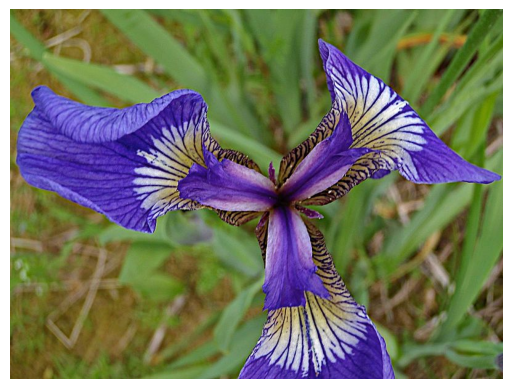

In [25]:
print_image_information("/Users/olehh/UiA/IKT213_Haugholt/assignment_1/iris-1.jpg")

In [ ]:
# Use camera and save the output to a video file and txt file

cam = cv2.VideoCapture(0)

frame_width = int(cam.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cam.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cam.get(cv2.CAP_PROP_FPS)

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('camera_output.mp4', fourcc, 20.0, (frame_width, frame_height))


while True:
    ret, frame = cam.read()
    if not ret:
        break

    # Write the frame to the output video
    out.write(frame)

    # Display the frame
    cv2.imshow('Frame', frame)

    # Break the loop if 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

with open('solutions/camera_output.txt', 'w') as f:
    f.write(f"Frame Width: {frame_width}\n")
    f.write(f"Frame Height: {frame_height}\n")
    f.write(f"FPS: {fps}\n")

# Release everything
cam.release()
out.release()
cv2.destroyAllWindows()